# Tutorial: Multiple Myeloma Datasets
## Notebook 01 — Image Presentation

This notebook presents the two public plasma cell datasets supporting Multiple Myeloma diagnosis:

| # | Dataset | Paper | Model |
|---|---------|--------|--------|
| 1 | [Multiple Myeloma Dataset](https://github.com/LabIA-UFBA/Multiple-Myeloma-Dataset) | Andrade et al. (2024), *Scientific Reports* 14:11176 | YOLOv7 |
| 2 | [PCMMD](https://github.com/LabIA-UFBA/MMDB) | Andrade et al. (2025), *Scientific Data* 12:161 | YOLOv8 |

**What you will learn:**
- Structure of an object detection dataset for medical images
- YOLO annotation format (normalized bounding boxes)
- How to load and visualize histological bone marrow images
- Differences between plasma and non-plasma cells

**Clinical context:** Multiple Myeloma (MM) is a hematologic neoplasm characterized by the proliferation of malignant plasma cells in the bone marrow. The gold-standard diagnosis involves cytological analysis of Wright-Giemsa-stained bone marrow aspirate, looking for a plasma cell proportion greater than 10%.

---
## 0. Environment Setup

In [1]:
!pip install --upgrade pip
!pip install -q opencv-python-headless matplotlib huggingface_hub datasets Pillow numpy pandas

In [2]:
import os
import zipfile
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import cv2
from pathlib import Path
from huggingface_hub import hf_hub_download

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 9

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

print('Environment configured.')

Environment configured.


---
## Part 1 — Multiple Myeloma Dataset
### Andrade et al. (2024) — *Scientific Reports*

**Dataset characteristics:**
- **1,024 images** of bone marrow aspirate slides
- **Wright-Giemsa** staining (morphological study)
- Captured with a **smartphone attached to the microscope**
- **Bounding box** annotations by experts (YOLO format)
- Cross-validation across **10 folds**
- Hosted on Hugging Face: `LAB-IA-UFBA/myeloma-dataset`

### 1.1 Data Download

In [3]:
DS1_DIR = DATA_DIR / 'dataset1'
DS1_ZIP = DATA_DIR / 'myeloma_dataset_conf_fold_1.zip'

if not DS1_DIR.exists():
    print('Downloading Dataset 1 (sample fold) from Hugging Face...')
    local_path = hf_hub_download(
        repo_id='LAB-IA-UFBA/myeloma-dataset',
        filename='myeloma_dataset_conf_fold_1.zip',
        repo_type='dataset',
        local_dir=str(DATA_DIR)
    )
    print(f'Download complete: {local_path}')
    print('Extracting files...')
    with zipfile.ZipFile(local_path, 'r') as zf:
        zf.extractall(DS1_DIR)
    print('Extraction complete.')
else:
    print(f'Dataset 1 already available at {DS1_DIR}')

Dataset 1 already available at data/dataset1


### 1.2 Data Structure

The dataset follows the standard **YOLO** structure:
```
fold_1/
├── train/
│   ├── images/   ← .jpg images
│   └── labels/   ← .txt annotations (YOLO format)
└── test/
    ├── images/
    └── labels/
```

**YOLO format (bounding box):**  
Each line of the `.txt` file represents one annotated cell:
```
class  cx  cy  width  height
```
All values are **normalized** by the image size (between 0 and 1).

In [4]:
# Explore the extracted folder structure
for root, dirs, files in os.walk(DS1_DIR):
    depth = root.replace(str(DS1_DIR), '').count(os.sep)
    indent = '  ' * depth
    folder_name = os.path.basename(root)
    n_files = len(files)
    if n_files > 0:
        print(f'{indent}{folder_name}/  ({n_files} files)')
    else:
        print(f'{indent}{folder_name}/')

dataset1/
  fold_1/
    train/  (1 files)
      labels/  (409 files)
      images/  (409 files)
    test/  (1 files)
      labels/  (53 files)
      images/  (53 files)
    val/  (1 files)
      labels/  (50 files)
      images/  (50 files)


In [5]:
# Find the images and labels folders
img_dirs  = sorted(DS1_DIR.rglob('images'))
lbl_dirs  = sorted(DS1_DIR.rglob('labels'))

# List all available images
all_images = []
for img_dir in img_dirs:
    all_images.extend(sorted(img_dir.glob('*.jpg')))

print(f'Total images found: {len(all_images)}')
print(f'Example path: {all_images[0] if all_images else "none"}')

Total images found: 512
Example path: data/dataset1/fold_1/test/images/1692243677913.jpg


### 1.3 Visualization: Raw Images

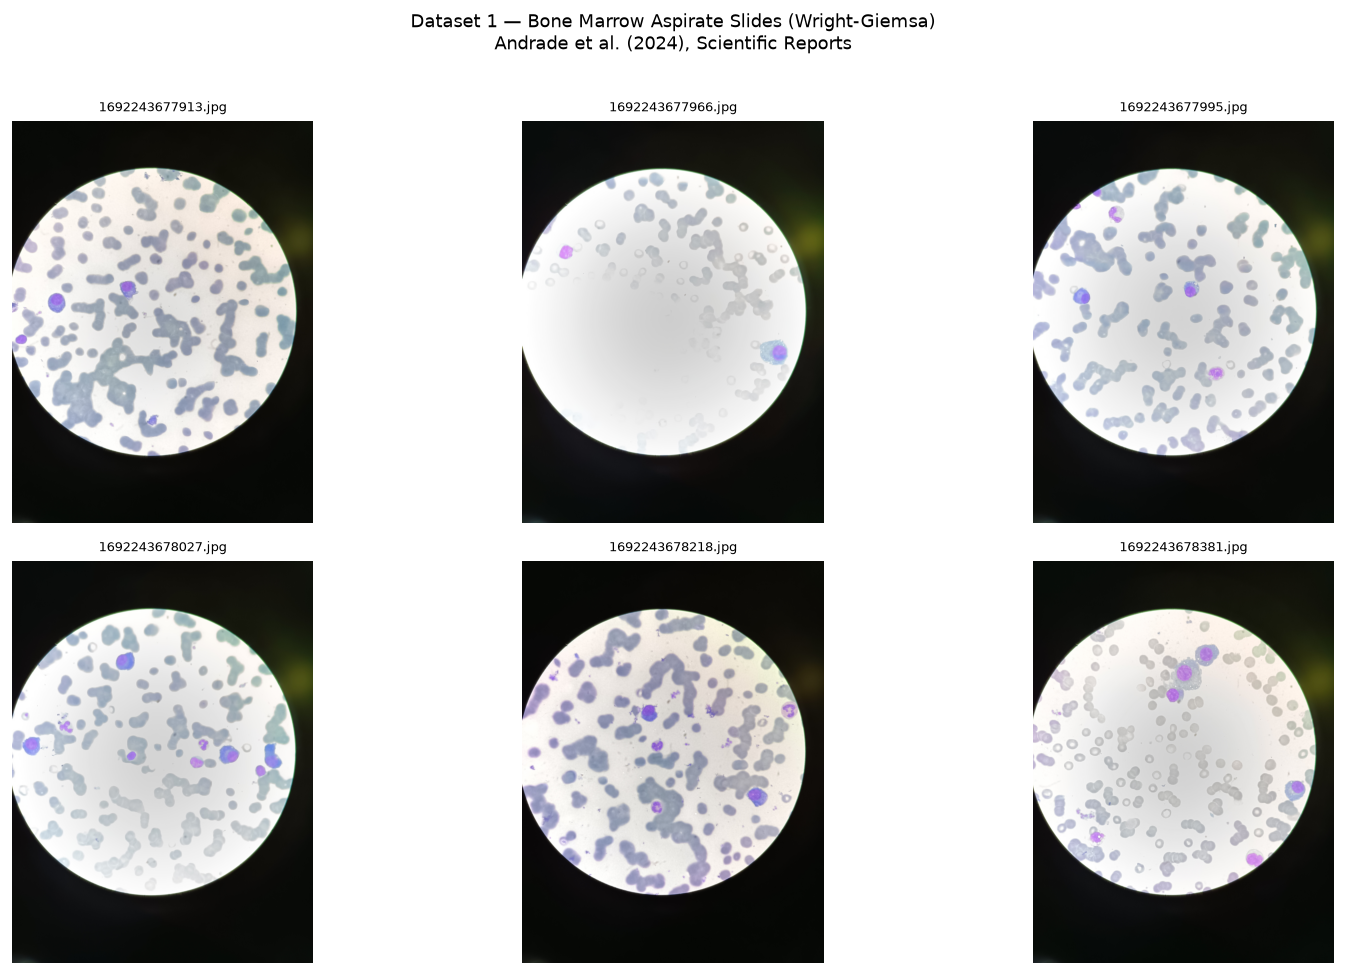

Example resolution: 3000×4000 px


In [6]:
def load_rgb(path):
    """Read an image and convert it to RGB."""
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show the first 6 images without annotations
n = min(6, len(all_images))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Dataset 1 — Bone Marrow Aspirate Slides (Wright-Giemsa)\nAndrade et al. (2024), Scientific Reports', fontsize=11, y=1.01)

for ax, img_path in zip(axes.flat, all_images[:n]):
    img = load_rgb(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Example resolution: {img.shape[1]}×{img.shape[0]} px')

### 1.4 Visualization: Annotated Images (Bounding Boxes)

In [19]:
# Dataset 1 class names and colors
# See the repository's YOLO config file (.yaml) for the exact names
DS1_CLASSES = {
    0: ('Plasma Cell', (255, 50,  50)),   # red
}

def yolo_to_pixel(cx, cy, bw, bh, W, H):
    """Convert normalized YOLO coordinates to pixels."""
    x1 = int((cx - bw / 2) * W)
    y1 = int((cy - bh / 2) * H)
    x2 = int((cx + bw / 2) * W)
    y2 = int((cy + bh / 2) * H)
    return x1, y1, x2, y2

def draw_yolo_boxes(img, label_path, class_info=None, thickness=2):
    """Draw YOLO bounding boxes on an image (numpy RGB)."""
    img_out = img.copy()
    H, W = img_out.shape[:2]

    if not label_path.exists():
        return img_out, []

    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, bw, bh, W, H)

            name, color = (class_info or DS1_CLASSES).get(
                cls_id, (f'Class {cls_id}', (0, 255, 0))
            )
            # OpenCV uses BGR; img is already RGB, so we pass the color in RGB
            cv2.rectangle(img_out, (x1, y1), (x2, y2), color, thickness)
            cv2.putText(img_out, name, (x1, max(y1 - 5, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
            boxes.append({'cls': cls_id, 'name': name,
                          'cx': cx, 'cy': cy, 'bw': bw, 'bh': bh})
    return img_out, boxes

print('Annotation functions defined.')

Annotation functions defined.


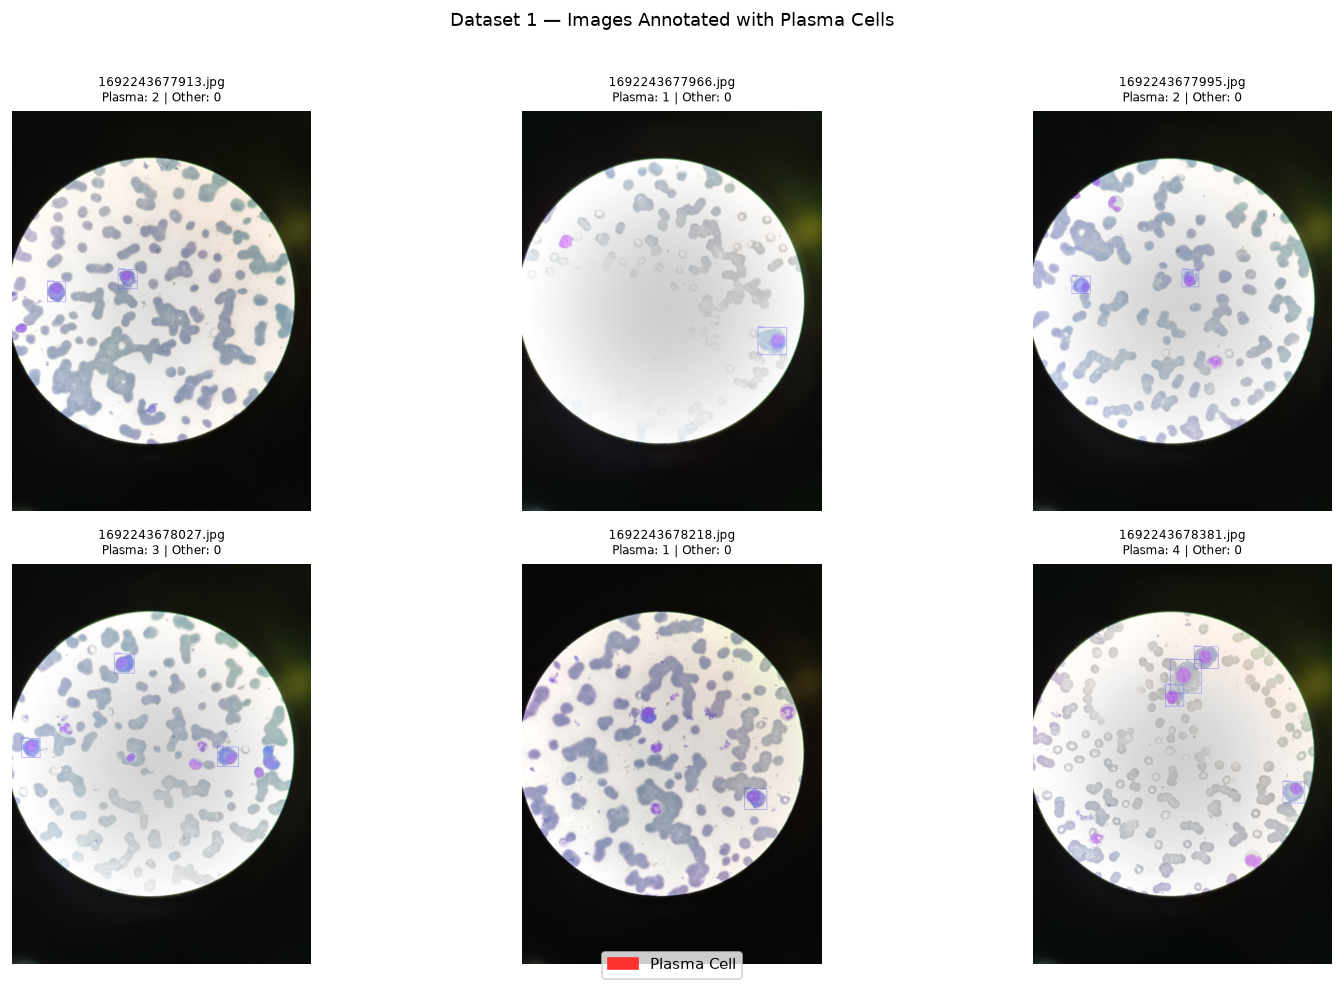

In [20]:
def find_label(img_path):
    """Find the labels file corresponding to an image."""
    lbl_path = Path(str(img_path).replace('/images/', '/labels/')).with_suffix('.txt')
    return lbl_path

# Show annotated images
n = min(6, len(all_images))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Dataset 1 — Images Annotated with Plasma Cells', fontsize=11, y=1.01)

for ax, img_path in zip(axes.flat, all_images[:n]):
    img      = load_rgb(img_path)
    lbl_path = find_label(img_path)
    annotated, boxes = draw_yolo_boxes(img, lbl_path, DS1_CLASSES, thickness=10)

    n_plasma = sum(1 for b in boxes if b['cls'] == 0)

    ax.imshow(annotated)
    ax.set_title(f'{img_path.name}\nPlasma cells: {n_plasma}', fontsize=7)
    ax.axis('off')

# Legend
patches = [mpatches.Patch(color=np.array(c) / 255, label=n)
           for cls_id, (n, c) in DS1_CLASSES.items()]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

### 1.5 Zoom on Plasma Cells

Plasma cells (plasmocytes) present distinct morphological features:
- **Basophilic** cytoplasm (intense blue-purple) due to high ribosomal RNA content
- **Eccentric** nucleus with chromatin condensed in a "cartwheel" pattern
- **Perinuclear** clear zone (Golgi apparatus)
- Moderate size (10–20 μm)

In [9]:
def crop_boxes(img, label_path, class_id=0, padding=10):
    """Crop the cells of a specific class from the bounding boxes."""
    H, W = img.shape[:2]
    crops = []

    if not label_path.exists():
        return crops

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5 or int(parts[0]) != class_id:
                continue
            cx, cy, bw, bh = map(float, parts[1:5])
            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, bw, bh, W, H)
            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(W, x2 + padding)
            y2 = min(H, y2 + padding)
            crops.append(img[y1:y2, x1:x2])
    return crops

# Collect plasma cell crops
plasma_crops = []
for img_path in all_images:
    img  = load_rgb(img_path)
    lbl  = find_label(img_path)
    plasma_crops.extend(crop_boxes(img, lbl, class_id=0))
    if len(plasma_crops) >= 20:
        break

print(f'Plasma cell crops obtained: {len(plasma_crops)}')

Plasma cell crops obtained: 20


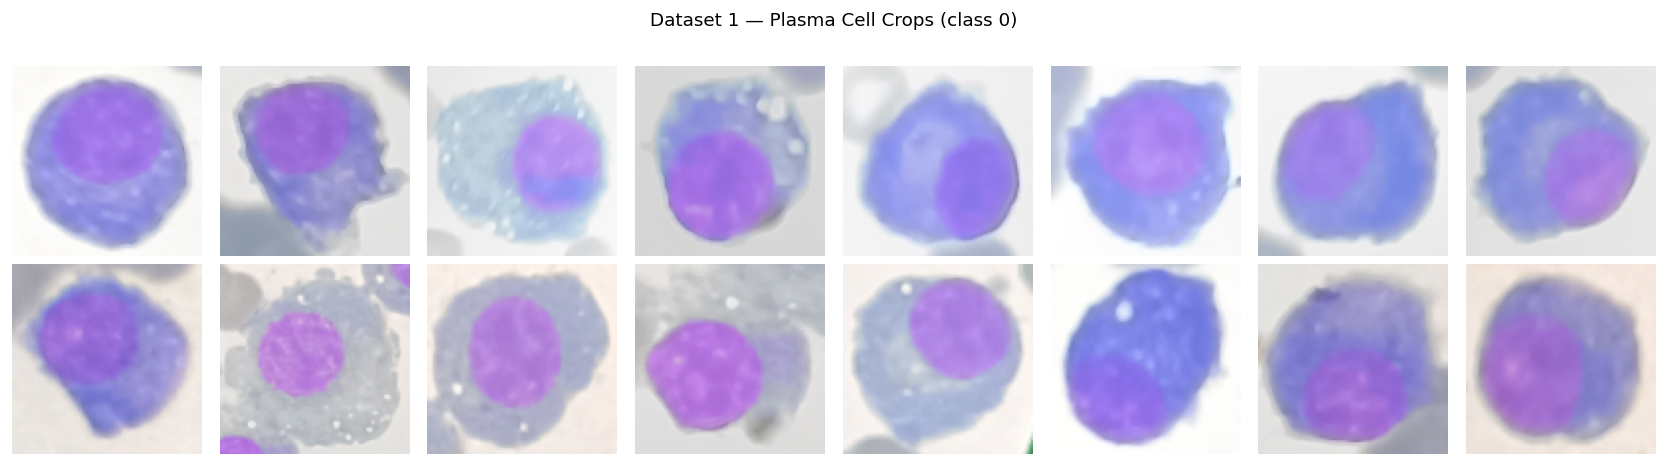

In [10]:
if plasma_crops:
    n_show = min(16, len(plasma_crops))
    cols = 8
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 2))
    fig.suptitle('Dataset 1 — Plasma Cell Crops (class 0)', fontsize=11)

    for ax, crop in zip(axes.flat, plasma_crops[:n_show]):
        # Resize for uniform display
        crop_resized = cv2.resize(crop, (96, 96))
        ax.imshow(crop_resized)
        ax.axis('off')

    for ax in axes.flat[n_show:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('No crops found. Check whether the labels contain class 0.')

### 1.6 Label Analysis

In [9]:
# Annotation statistics
records = []
for img_path in all_images:
    lbl_path = find_label(img_path)
    if not lbl_path.exists():
        continue
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                records.append({
                    'image':  img_path.name,
                    'class':  int(parts[0]),
                    'cx':     float(parts[1]),
                    'cy':     float(parts[2]),
                    'width':  float(parts[3]),
                    'height': float(parts[4]),
                })

df = pd.DataFrame(records)
if not df.empty:
    df['relative_area'] = df['width'] * df['height']

    print('=== Annotation Summary ===')
    print(f'Total annotated cells   : {len(df)}')
    print(f'Total images            : {df["image"].nunique()}')
    print(f'Average cells/image     : {len(df) / df["image"].nunique():.1f}')
    print()
    print('Distribution by class:')
    print(df['class'].value_counts().rename(index=lambda c: DS1_CLASSES.get(c, (f'Class {c}',))[0]))
    print()
    print('Average bounding box size (relative to image):')
    print(df.groupby('class')[['width', 'height', 'relative_area']].mean().round(4))
else:
    print('No labels found. Check the folder structure.')

=== Annotation Summary ===
Total annotated cells   : 1615
Total images            : 512
Average cells/image     : 3.2

Distribution by class:
class
Plasma Cell    1615
Name: count, dtype: int64

Average bounding box size (relative to image):
        width  height  relative_area
class                               
0      0.0867  0.0838         0.0087


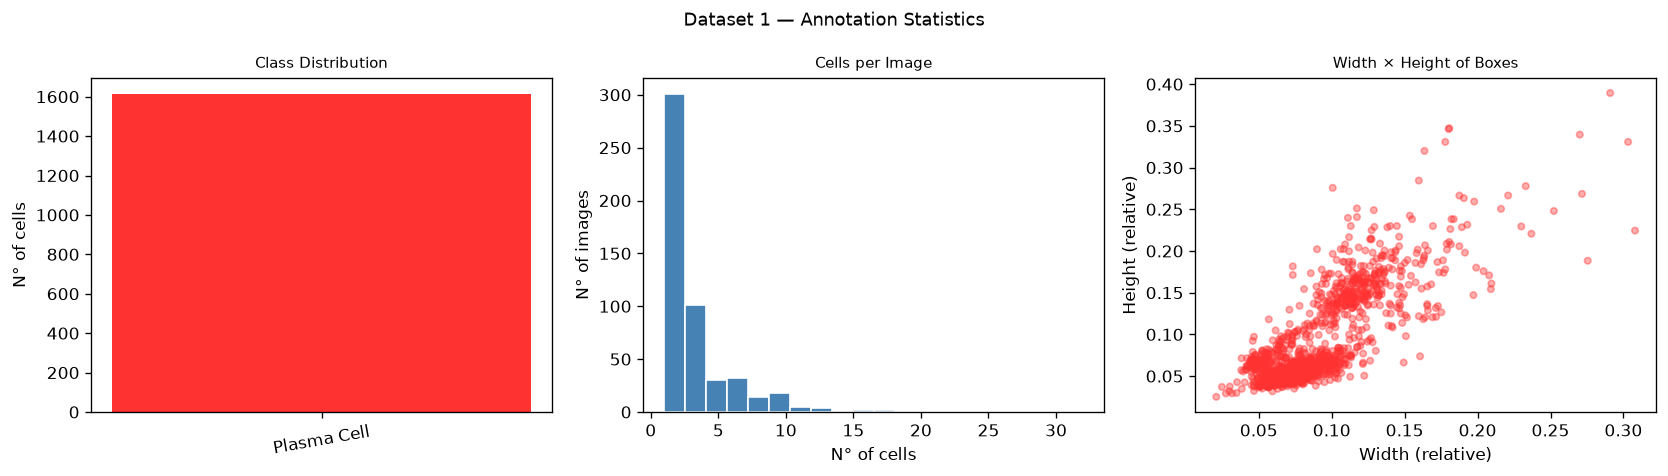

In [10]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('Dataset 1 — Annotation Statistics', fontsize=11)

    # Class distribution
    class_counts = df['class'].value_counts().sort_index()
    labels = [DS1_CLASSES.get(c, (f'Class {c}',))[0] for c in class_counts.index]
    colors = [np.array(DS1_CLASSES.get(c, ('', (100, 100, 100)))[1]) / 255 for c in class_counts.index]
    axes[0].bar(labels, class_counts.values, color=colors)
    axes[0].set_title('Class Distribution')
    axes[0].set_ylabel('N° of cells')
    axes[0].tick_params(axis='x', rotation=10)

    # Number of cells per image
    per_img = df.groupby('image').size()
    axes[1].hist(per_img, bins=20, color='steelblue', edgecolor='white')
    axes[1].set_title('Cells per Image')
    axes[1].set_xlabel('N° of cells')
    axes[1].set_ylabel('N° of images')

    # Relative bounding box size
    axes[2].scatter(df['width'], df['height'],
                    c=[np.array(DS1_CLASSES.get(c, ('', (100,100,100)))[1]) / 255
                       for c in df['class']],
                    alpha=0.4, s=15)
    axes[2].set_title('Width × Height of Boxes')
    axes[2].set_xlabel('Width (relative)')
    axes[2].set_ylabel('Height (relative)')

    plt.tight_layout()
    plt.show()

---
## Part 2 — PCMMD: Plasma Cell Multiple Myeloma Dataset
### Andrade et al. (2025) — *Scientific Data*

**Dataset characteristics:**
- **10 patients** (real clinical cases)
- Two tasks: **detection** (full images) and **segmentation** (masked crops)
- Cross-validation across **5 folds**
- Model: **YOLOv8** (pre-trained weights available in the repository)
- License: **CC-BY-4.0**

### 2.1 Data Download

In [11]:
DS2_DIR = DATA_DIR / 'MMDB'

if not DS2_DIR.exists():
    print('Cloning MMDB repository...')
    result = subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/LabIA-UFBA/MMDB.git',
         str(DS2_DIR)],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('Clone complete.')
    else:
        print('Clone error:')
        print(result.stderr)
else:
    print(f'Repository already available at {DS2_DIR}')

Cloning MMDB repository...
Clone complete.


In [12]:
# Explore the MMDB structure
for root, dirs, files in os.walk(DS2_DIR):
    # Skip the .git folder
    dirs[:] = [d for d in dirs if d != '.git']
    depth = root.replace(str(DS2_DIR), '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    folder_name = os.path.basename(root) or 'MMDB'
    n_files = len(files)
    if n_files > 0:
        exts = set(Path(f).suffix for f in files)
        print(f'{indent}{folder_name}/  ({n_files} files: {exts})')
    else:
        print(f'{indent}{folder_name}/')

MMDB/  (3 files: {'', '.md'})
  src/  (3 files: {'.pt', '.ipynb'})
  data/
    detection/  (11 files: {'.txt', '.yaml'})
      train/
      patients/  (1 files: {'.csv'})
    segmentation/
      non-plasma cells/
      plasma cells/


### 2.2 Detection — Patient Images with Annotations

In [13]:
# Locate the detection images
det_img_dirs = list((DS2_DIR / 'data' / 'detection').rglob('images'))
print('Detection image directories:')
for d in det_img_dirs:
    imgs_in_dir = list(d.glob('*.jpg')) + list(d.glob('*.png'))
    print(f'  {d.relative_to(DS2_DIR)}  ({len(imgs_in_dir)} images)')

Detection image directories:
  data/detection/train/images  (512 images)
  data/detection/patients/patient 10/images  (49 images)
  data/detection/patients/patient 04/images  (33 images)
  data/detection/patients/patient 05/images  (37 images)
  data/detection/patients/patient 08/images  (20 images)
  data/detection/patients/patient 06/images  (29 images)
  data/detection/patients/patient 01/images  (34 images)
  data/detection/patients/patient 07/images  (21 images)
  data/detection/patients/patient 09/images  (49 images)
  data/detection/patients/patient 02/images  (32 images)
  data/detection/patients/patient 03/images  (40 images)


In [14]:
# MMDB class names and colors
DS2_CLASSES = {
    0: ('Plasma Cell',     (220, 50,  50)),   # red
    1: ('Non-Plasma Cell', (50,  100, 220)),   # blue
}

# Collect available detection images
det_images = []
for img_dir in det_img_dirs:
    det_images.extend(sorted(img_dir.glob('*.jpg')))
    det_images.extend(sorted(img_dir.glob('*.png')))

print(f'Total detection images: {len(det_images)}')

if det_images:
    img_path = det_images[0]
    img = load_rgb(img_path)
    print(f'Example image: {img_path.name}  —  {img.shape[1]}×{img.shape[0]} px')

Total detection images: 856
Example image: 1692243677854.jpg  —  3000×4000 px


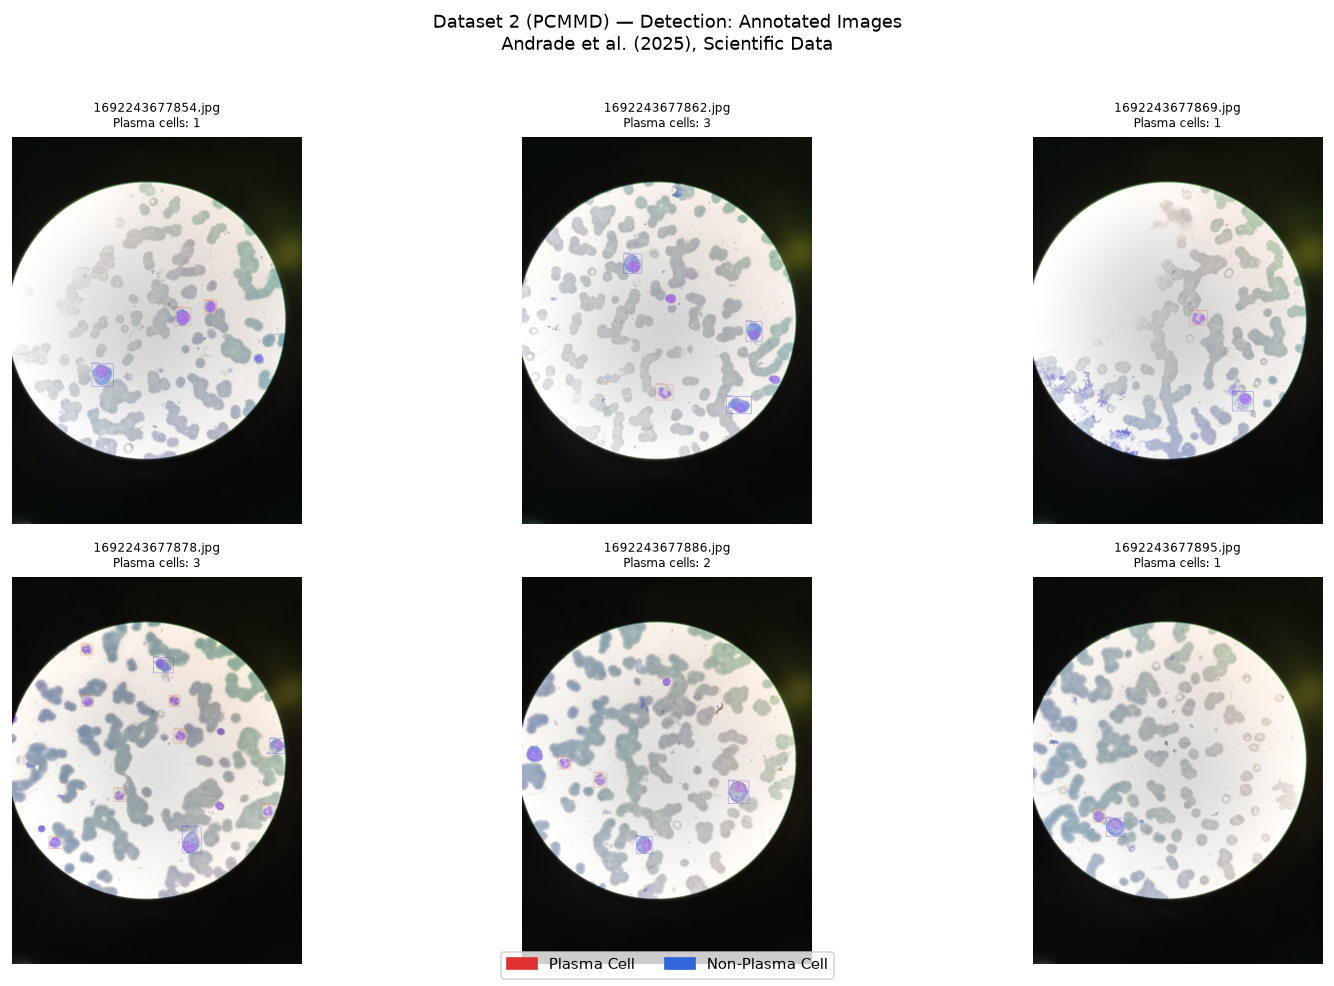

In [15]:
if det_images:
    n = min(6, len(det_images))
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle('Dataset 2 (PCMMD) — Detection: Annotated Images\nAndrade et al. (2025), Scientific Data', fontsize=11, y=1.01)

    for ax, img_path in zip(axes.flat, det_images[:n]):
        img      = load_rgb(img_path)
        lbl_path = find_label(img_path)
        annotated, boxes = draw_yolo_boxes(img, lbl_path, DS2_CLASSES, thickness=10)
        n_plasma = sum(1 for b in boxes if b['cls'] == 0)
        n_other  = sum(1 for b in boxes if b['cls'] == 1)

        ax.imshow(annotated)
        ax.set_title(f'{img_path.name[:30]}\nPlasma: {n_plasma} | Non-Plasma: {n_other}', fontsize=7)
        ax.axis('off')

    for ax in axes.flat[n:]:
        ax.set_visible(False)

    patches = [mpatches.Patch(color=np.array(c) / 255, label=nm)
               for _, (nm, c) in DS2_CLASSES.items()]
    fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No detection images found in data/detection/.')

### 2.3 Segmentation — Crops with Binary Mask

The **segmentation** task operates on individual cell crops.  
For each crop there is a **binary mask** (0 = background, 255 = cell) that precisely delimits the cell contour.

In [16]:
seg_dir = DS2_DIR / 'data' / 'segmentation'

# Expected structure: seg_dir/{class}/images/ and seg_dir/{class}/masks/
seg_classes = sorted([d for d in seg_dir.iterdir() if d.is_dir()]) if seg_dir.exists() else []

seg_images = {}
seg_masks  = {}

for cls_dir in seg_classes:
    imgs = sorted((cls_dir / 'images').glob('*.*')) if (cls_dir / 'images').exists() else []
    masks = sorted((cls_dir / 'masks').glob('*.*'))  if (cls_dir / 'masks').exists()  else []
    if imgs:
        seg_images[cls_dir.name] = imgs
        seg_masks[cls_dir.name]  = masks
        print(f'  {cls_dir.name}: {len(imgs)} images, {len(masks)} masks')

# Fallback: search for images at the segmentation root
if not seg_images and seg_dir.exists():
    all_seg_imgs = list(seg_dir.rglob('*.jpg')) + list(seg_dir.rglob('*.png'))
    print(f'Segmentation images found: {len(all_seg_imgs)}')
    for p in all_seg_imgs[:5]:
        print(f'  {p.relative_to(DS2_DIR)}')

  non-plasma cells: 1931 images, 1927 masks
  plasma cells: 1615 images, 1613 masks


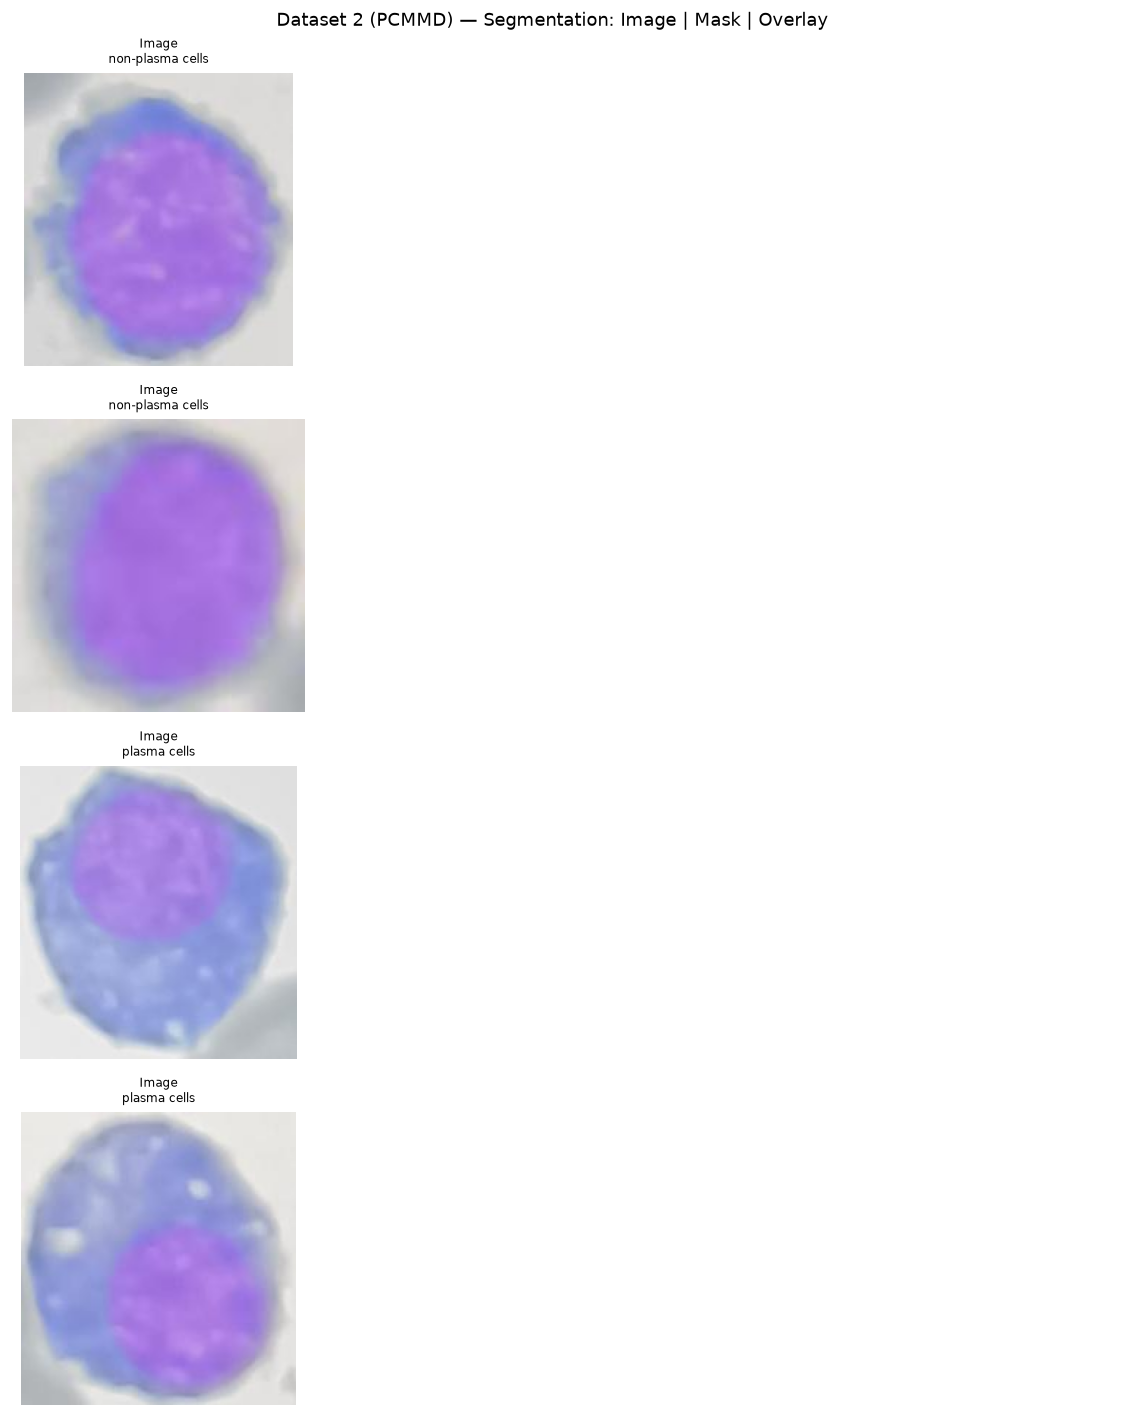

In [17]:
def show_segmentation_triplet(img_path, mask_path, ax_img, ax_mask, ax_overlay, title=''):
    """Show image, mask, and overlay side by side."""
    img  = load_rgb(img_path)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path and mask_path.exists() else None

    ax_img.imshow(img)
    ax_img.set_title(f'Image\n{title}', fontsize=7)
    ax_img.axis('off')

    if mask is not None:
        ax_mask.imshow(mask, cmap='gray')
        ax_mask.set_title('Mask', fontsize=7)
        ax_mask.axis('off')

        # Overlay: mask in semi-transparent green
        overlay = img.copy()
        green_mask = np.zeros_like(img)
        green_mask[:, :, 1] = mask
        overlay = cv2.addWeighted(overlay, 0.6, green_mask, 0.4, 0)
        ax_overlay.imshow(overlay)
        ax_overlay.set_title('Overlay', fontsize=7)
        ax_overlay.axis('off')
    else:
        ax_mask.axis('off')
        ax_overlay.axis('off')

if seg_images:
    # Select 2 samples from each class
    sample_items = []
    for cls_name, imgs in seg_images.items():
        masks = seg_masks.get(cls_name, [])
        for i, img_p in enumerate(imgs[:2]):
            mask_p = masks[i] if i < len(masks) else None
            sample_items.append((cls_name, img_p, mask_p))

    n_samples = len(sample_items)
    fig, axes = plt.subplots(n_samples, 3, figsize=(10, n_samples * 3))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('Dataset 2 (PCMMD) — Segmentation: Image | Mask | Overlay', fontsize=11)

    for row, (cls_name, img_p, mask_p) in enumerate(sample_items):
        show_segmentation_triplet(img_p, mask_p,
                                  axes[row, 0], axes[row, 1], axes[row, 2],
                                  title=cls_name)
        axes[row, 0].set_ylabel(cls_name, fontsize=8, rotation=90, labelpad=4)

    plt.tight_layout()
    plt.show()
else:
    print('Segmentation data not found in data/segmentation/.')
    print('Check whether the MMDB repository was cloned correctly and the data is present.')

---
## Part 3 — Dataset Comparison

| Aspect | Dataset 1 (Sci. Reports 2024) | Dataset 2 — PCMMD (Sci. Data 2025) |
|---------|-------------------------------|-------------------------------------|
| Images | 1,024 full slides | Per-patient images (10 cases) |
| Tasks | Detection | Detection + Segmentation |
| Acquisition | Smartphone + microscope | Digital microscope |
| Validation | 10-fold CV | 5-fold CV |
| Model | YOLOv7 | YOLOv8 |
| License | GPL-3.0 | CC-BY-4.0 |

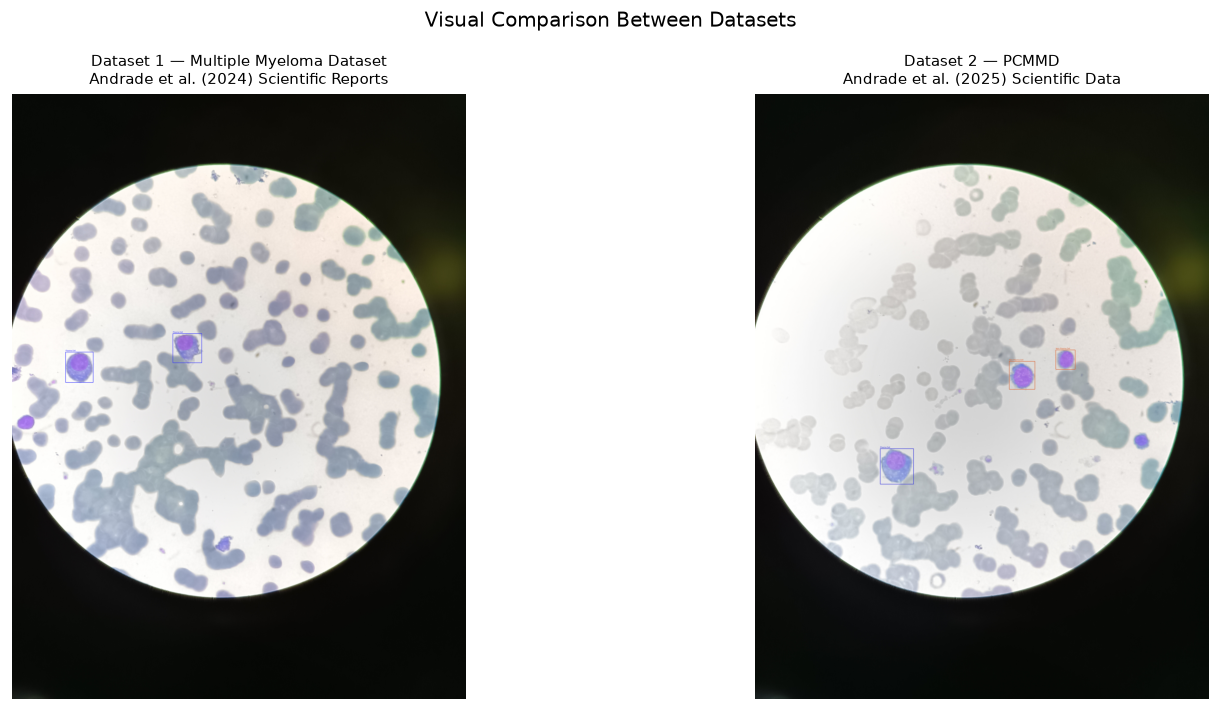

In [18]:
# Visual comparison: one sample from each dataset side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Visual Comparison Between Datasets', fontsize=12)

# Dataset 1
if all_images:
    img1      = load_rgb(all_images[0])
    lbl1      = find_label(all_images[0])
    ann1, _   = draw_yolo_boxes(img1, lbl1, DS1_CLASSES)
    axes[0].imshow(ann1)
    axes[0].set_title('Dataset 1 — Multiple Myeloma Dataset\nAndrade et al. (2024) Scientific Reports', fontsize=9)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Dataset 1\nnot loaded', ha='center', va='center')
    axes[0].axis('off')

# Dataset 2
if det_images:
    img2      = load_rgb(det_images[0])
    lbl2      = find_label(det_images[0])
    ann2, _   = draw_yolo_boxes(img2, lbl2, DS2_CLASSES)
    axes[1].imshow(ann2)
    axes[1].set_title('Dataset 2 — PCMMD\nAndrade et al. (2025) Scientific Data', fontsize=9)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Dataset 2\nnot loaded', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Summary

In this notebook you learned how to:

1. **Download** the datasets from Hugging Face and GitHub
2. **Inspect** the folder structure of a YOLO dataset
3. **Visualize** histological bone marrow aspirate images
4. **Draw** bounding boxes from YOLO-format annotations
5. **Crop** individual cells for morphological analysis
6. **Display** segmentation images with mask overlay

**References:**
- Andrade et al. (2024). *Multiple Myeloma Dataset*. Scientific Reports, 14, 11176. https://doi.org/10.1038/s41598-024-61420-9
- Andrade et al. (2025). *PCMMD*. Scientific Data, 12, 161. https://doi.org/10.1038/s41597-025-04459-1